# 03 — 第二代：Model-based Filtering

**方法论定位（第二代）**：训练 fastText 质量分类器，保留 top-10% 的文档。

**DCLM 的核心发现（NeurIPS 2024）**：
- fastText 二分类器（dim=64, wordNgrams=2）+ top-10% 阈值，效果超过所有 heuristic 组合
- Perplexity 过滤、PageRank、语义去重等方法都不如这个简单方案
- 7B 模型训练后 MMLU 达到 64%（接近 Llama 3 8B 的 66%，但只用了 1/6.6 的算力）

**与第一代的本质区别**：
- 第一代过滤"长相不像自然文本的文档"（乱码、广告等）
- 第二代过滤"语义上不像高质量写作的文档"（平庸内容）
- 这是质量评估维度的根本跃升

## Cell Group A: 加载 Gen2 Pipeline 预计算结果

> **本 notebook 读取预计算的 pipeline 输出，不执行 pipeline 本身。**

### fastText 简介：为什么它适合大规模文本分类？

fastText 是 Facebook Research 开源的文本分类工具（Joulin et al. 2016）。它的核心思路非常简单：

```
输入文本 → 拆成词和字符 n-gram → 查表取向量 → 求平均 → 线性分类器 → 输出标签
```

**具体过程**（以 `dim=64, wordNgrams=2` 为例）：
1. **文本表征**：把文本拆成词（如 `"the cat sat"`）和字符 n-gram（如 `"th"`, `"he"`, `"ca"`, `"at"` 等），每个片段查一张可训练的向量表，得到一个 64 维向量
2. **聚合**：把文本中所有片段的向量取**平均**，得到整篇文档的一个 64 维向量
3. **分类**：这个向量经过一层线性变换（矩阵乘法 + softmax），输出"高质量"或"低质量"的概率

**为什么极快？** 整个模型只有"查表 + 平均 + 一层线性"，没有 Transformer 的多层注意力计算。处理一篇文档就是几次查表和一次矩阵乘法，所以 50K 文档不到 1 分钟。作为对比，BERT 需要 12 层 Transformer 逐 token 计算注意力，慢约 100 倍。

**关键超参数**：
- `dim=64`：每个词/n-gram 的向量维度。越高表达能力越强，但训练更慢
- `wordNgrams=2`：除了单个词，还考虑相邻两个词的组合（如 `"the cat"`）。这让模型能捕捉短语级别的模式，而不只是单词

> **fastText vs BERT 的速度-效果对比**：详见 NB00 §1.2 的对比表。DCLM 结论：在 TB 级数据清洗场景下，fastText 的速度优势（~100x）远大于 BERT 的精度优势（AUC +0.07, MMLU +2pp）。

### 分类器配置

| 项目 | 本项目配置 | DCLM 论文配置 |
|------|-----------|--------------|
| 正样本 | Wikipedia 摘要（详见 NB00 §2.2） | Wikipedia + OpenHermes（论文同时测试两种） |
| 负样本 | 原始 CC WET 随机样本 | DCLM-Pool 随机样本（~240B tokens） |
| 模型 | fastText | fastText（论文最优方案） |
| 超参 | dim=64, wordNgrams=2 | dim=64, wordNgrams=2（DCLM Table 2 最优） |
| 阈值 | top-10% | top-10%（Table 3：7B MMLU 最优） |

> **DCLM 论文核心结论**：top-10% 阈值 → 7B MMLU 64%（接近 Llama 3 8B 的 66%，仅用 1/6.6 算力）。MMLU 口径同 NB00 §1 首表。阈值实验详见 NB00 §1.2。

### 评估分类器独立性

> ⚠️ **评估分类器与 Pipeline 分类器独立训练**
>
> - Pipeline 分类器：正样本 = `wikipedia_abstracts.jsonl`，dim=64, wordNgrams=2
> - 评估分类器：正样本 = `wikipedia_abstracts_eval.jsonl`（独立数据集，与 Pipeline 用的完全不重叠），dim=32, wordNgrams=3
> - 独立性保障：正样本数据集不重叠 + 超参数不同（双重独立），避免循环偏差。详见 NB00 §1.2。

In [ ]:
# === Cell A: 加载配置 + Gen2 统计 + Gen1/Gen2 输出文档 ===
# 从预计算结果文件加载，不执行任何 pipeline 代码。
# 仅导入 config_loader（配置）和 EvalQualityClassifier（独立评估打分）。

import sys, json
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
from pathlib import Path

from src.utils.config_loader import load_run_config, get_output_path, print_config_summary
from src.evaluation.quality_classifier import EvalQualityClassifier

# --- 配置 ---
run_cfg = load_run_config()
print_config_summary(run_cfg)
mode = run_cfg.get('run_mode', 'smoke_test')

# --- 路径（根据 run_mode 自动定位） ---
gen1_dir = get_output_path(1, run_cfg)
gen2_dir = get_output_path(2, run_cfg)

# --- 依赖文件校验 ---
REQUIRED_FILES = {
    'Gen2 统计': gen2_dir / 'gen2_stats.json',
    'Gen1 输出': gen1_dir / 'gen1_output.jsonl',
    'Gen2 输出': gen2_dir / 'gen2_output.jsonl',
    '评估分类器': Path('../results/quality_scores/eval_classifier.bin'),
}
for name, path in REQUIRED_FILES.items():
    assert path.exists(), f"缺少 {name}: {path}，请先运行 scripts/run_gen2.py"

# --- 读取 Gen2 统计 ---
stats_path = gen2_dir / 'gen2_stats.json'
with open(stats_path) as f:
    gen2_stats = json.load(f)

print(f"\nGen2 Pipeline 统计 [{mode}]:")
print(f"  输入文档数: {gen2_stats['input_count']:,}")
print(f"  输出文档数: {gen2_stats['output_count']:,}")
print(f"  保留率:     {gen2_stats['retention_rate']:.2%}")
print(f"  top_fraction: {gen2_stats['top_fraction']}")
print(f"  阈值:       {gen2_stats['threshold']:.4f}")
print(f"  分数均值:   {gen2_stats['score_stats']['mean']:.4f}")
print(f"  分数 P50:   {gen2_stats['score_stats']['p50']:.4f}")
print(f"  分数 P90:   {gen2_stats['score_stats']['p90']:.4f}")

# --- 读取文档 ---
def read_jsonl(path, limit=None):
    docs = []
    with open(path, encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            docs.append(json.loads(line))
    return docs

gen1_docs = read_jsonl(gen1_dir / 'gen1_output.jsonl')
gen2_docs = read_jsonl(gen2_dir / 'gen2_output.jsonl')

print(f"\nGen1 输出文档: {len(gen1_docs):,} 条（Gen2 的输入）")
print(f"Gen2 输出文档: {len(gen2_docs):,} 条（top-{gen2_stats['top_fraction']:.0%} 保留）")

# --- 加载评估分类器 ---
eval_clf = EvalQualityClassifier()
eval_clf_path = Path('../results/quality_scores/eval_classifier.bin')
eval_clf._load(str(eval_clf_path))

# --- 提取 Gen2 pipeline 打分 ---
# gen2_output.jsonl 中的 _gen2_score 是 pipeline 分类器的打分
gen2_pipeline_scores = np.array([d['_gen2_score'] for d in gen2_docs])
print(f"\nGen2 输出文档的 pipeline 分数范围: [{gen2_pipeline_scores.min():.4f}, {gen2_pipeline_scores.max():.4f}]")

## Cell Group B: 分数分布可视化

> Gen2 pipeline 对 Gen1 输出的全部文档打分，分数分布反映了文档质量的整体情况。
> 红色虚线标注 top-10% 阈值，右侧为保留区域。
> 直方图数据来自 `gen2_stats.json`（预计算）。

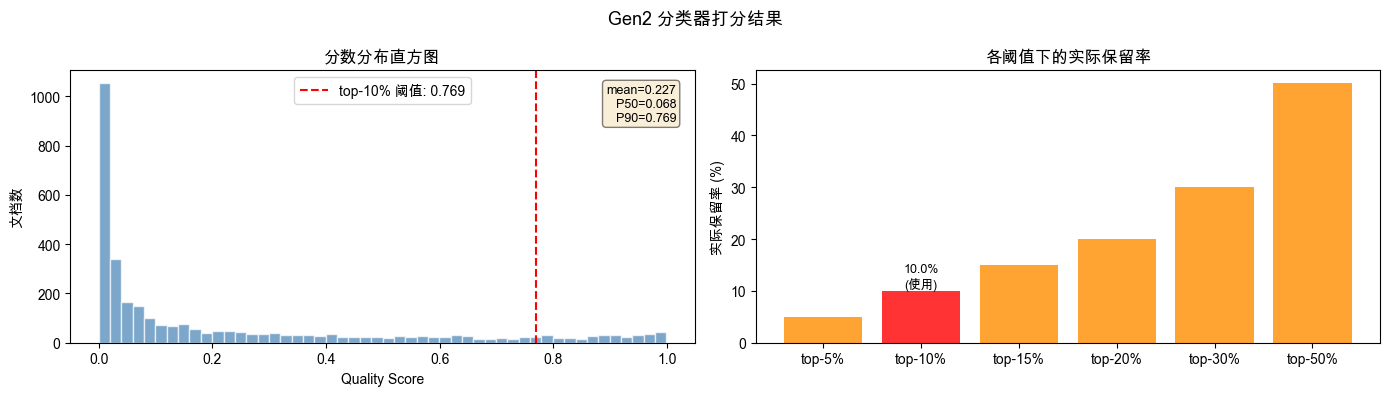

已保存: results/figures/03_gen2_score_distribution.png


In [2]:
# === Cell B: 分数分布直方图 ===
# 如果 gen2_stats 包含 score_histogram，直接绘制；
# 否则用评估分类器对 gen1 文档打分展示质量分布。

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

threshold = gen2_stats['threshold']
score_stats = gen2_stats['score_stats']

if 'score_histogram' in gen2_stats:
    # --- 从预计算的直方图数据绘制 ---
    counts = np.array(gen2_stats['score_histogram']['counts'])
    bin_edges = np.array(gen2_stats['score_histogram']['bin_edges'])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = bin_edges[1:] - bin_edges[:-1]
    axes[0].bar(bin_centers, counts, width=bin_widths, color='steelblue',
                alpha=0.7, edgecolor='white')
    all_scores = np.array(gen2_stats.get('all_scores', []))
else:
    # --- 用评估分类器对 gen1 文档打分（独立评估视角） ---
    print("gen2_stats 中无 score_histogram，用评估分类器对 Gen1 文档打分...")
    all_scores = eval_clf.score_batch([d['text'] for d in gen1_docs])
    axes[0].hist(all_scores, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    # 使用评估分类器的分布时，阈值改为 P90
    threshold = float(np.percentile(all_scores, 90))

axes[0].axvline(threshold, color='red', linestyle='--', linewidth=1.5,
                label=f'top-10% 阈值: {threshold:.3f}')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('文档数')
axes[0].set_title('分数分布直方图')
axes[0].legend()

# 标注统计量
stats_text = f"mean={score_stats['mean']:.3f}\nP50={score_stats['p50']:.3f}\nP90={score_stats['p90']:.3f}"
axes[0].text(0.97, 0.95, stats_text, transform=axes[0].transAxes,
             verticalalignment='top', horizontalalignment='right',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- 右图：各阈值下的保留率 ---
top_fractions = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
if len(all_scores) > 0:
    retained_pcts = [np.mean(all_scores >= np.percentile(all_scores, (1 - t) * 100)) * 100
                     for t in top_fractions]
else:
    retained_pcts = [t * 100 for t in top_fractions]

colors = ['darkorange' if t != gen2_stats['top_fraction'] else 'red'
          for t in top_fractions]
bars = axes[1].bar([f'top-{int(t*100)}%' for t in top_fractions],
                    retained_pcts, color=colors, alpha=0.8)
axes[1].set_ylabel('实际保留率 (%)')
axes[1].set_title('各阈值下的实际保留率')

# 标注实际使用的阈值
for bar, t, pct in zip(bars, top_fractions, retained_pcts):
    if t == gen2_stats['top_fraction']:
        axes[1].annotate(f'{pct:.1f}%\n(使用)', xy=(bar.get_x() + bar.get_width()/2, pct),
                         ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Gen2 分类器打分结果', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/03_gen2_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: results/figures/03_gen2_score_distribution.png")

## Cell Group C: Quality-Quantity Trade-off 曲线

> **DCLM 论文的关键问题：top-X% 的 X 应该设为多少？**
>
> 直觉上：X 越小（保留越少），质量越高；X 越大（保留越多），质量越低。
> 但实际上：X=5% 虽然质量最高，但 token 数量太少，在长 horizon 训练时效果反而不好。
>
> DCLM 的发现：top-10% 是质量x数量综合最优的点。
>
> 本 cell 用独立评估分类器在不同 top-X% 下计算质量均分和 Token 产出，
> 验证 DCLM 的结论。

  top- 5%:  163 条 | 质量均分: 0.8644 | Token: 206,690


  top-10%:  325 条 | 质量均分: 0.8441 | Token: 498,450
  top-15%:  488 条 | 质量均分: 0.8298 | Token: 716,857
  top-20%:  649 条 | 质量均分: 0.8186 | Token: 941,683
  top-30%:  973 条 | 质量均分: 0.7998 | Token: 1,330,225


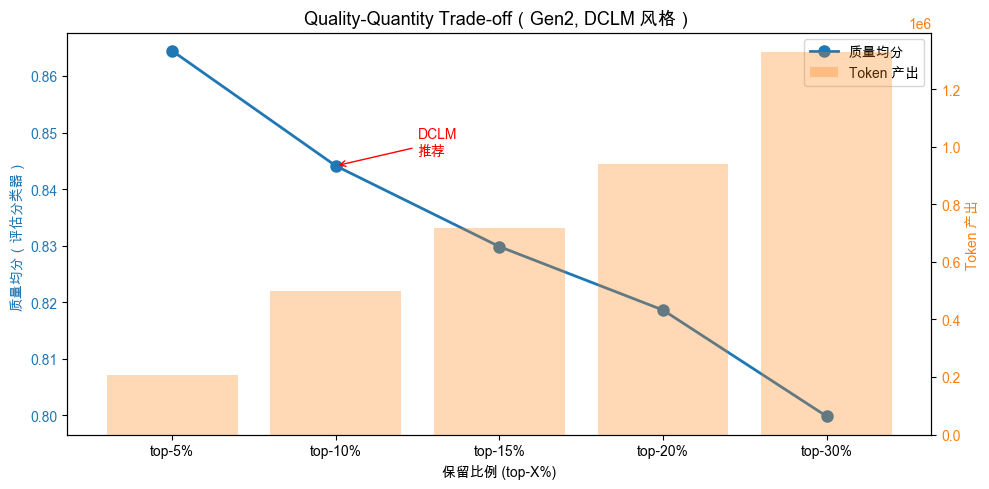

已保存: results/figures/03_gen2_tradeoff_curve.png

              threshold  retained_docs  retention_rate  quality_score_mean  quality_score_p90  estimated_total_tokens
top_fraction                                                                                                         
0.05           0.837966            163        0.050278            0.864442           0.894304                  206690
0.10           0.811612            325        0.100247            0.844107           0.877748                  498450
0.15           0.792221            488        0.150524            0.829832           0.870768                  716857
0.20           0.777164            649        0.200185            0.818612           0.866654                  941683
0.30           0.749178            973        0.300123            0.799837           0.855175                 1330225


In [3]:
# === Cell C: Quality-Quantity Trade-off 曲线 ===
# 用独立评估分类器在不同 top-X% 下计算质量均分，验证 DCLM 的 top-10% 最优结论。
# 评估分类器与 Pipeline 分类器独立训练，避免循环偏差。

# 对 Gen1 文档（Gen2 的输入）用评估分类器打分
gen1_texts = [d['text'] for d in gen1_docs]
eval_scores = eval_clf.score_batch(gen1_texts)

# 模拟不同 top-X% 阈值
top_fractions = [0.05, 0.10, 0.15, 0.20, 0.30]
tradeoff_rows = []

for frac in top_fractions:
    cutoff = np.percentile(eval_scores, (1 - frac) * 100)
    mask = eval_scores >= cutoff
    retained_docs = int(mask.sum())
    retained_texts = [t for t, m in zip(gen1_texts, mask) if m]
    total_tokens = sum(len(t.split()) for t in retained_texts)

    # 质量均分 = 被保留文档的评估分类器均分
    quality_mean = float(eval_scores[mask].mean()) if retained_docs > 0 else 0.0
    quality_p90 = float(np.percentile(eval_scores[mask], 90)) if retained_docs > 0 else 0.0

    tradeoff_rows.append({
        'top_fraction': frac,
        'threshold': float(cutoff),
        'retained_docs': retained_docs,
        'retention_rate': retained_docs / len(gen1_docs),
        'quality_score_mean': quality_mean,
        'quality_score_p90': quality_p90,
        'estimated_total_tokens': total_tokens,
    })
    print(f"  top-{int(frac*100):2d}%: {retained_docs:4d} 条 | "
          f"质量均分: {quality_mean:.4f} | Token: {total_tokens:,}")

tradeoff_df = pd.DataFrame(tradeoff_rows).set_index('top_fraction')

# --- 绘制 trade-off 双轴图 ---
fig, ax1 = plt.subplots(figsize=(10, 5))

color_quality = '#1f77b4'
color_tokens = '#ff7f0e'

x_labels = [f'top-{int(f*100)}%' for f in top_fractions]
x_pos = np.arange(len(top_fractions))

# 质量均分（左轴）
ax1.plot(x_pos, tradeoff_df['quality_score_mean'].values, 'o-',
         color=color_quality, linewidth=2, markersize=8, label='质量均分')
ax1.set_xlabel('保留比例 (top-X%)')
ax1.set_ylabel('质量均分（评估分类器）', color=color_quality)
ax1.tick_params(axis='y', labelcolor=color_quality)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)

# Token 产出（右轴）
ax2 = ax1.twinx()
ax2.bar(x_pos, tradeoff_df['estimated_total_tokens'].values,
        alpha=0.3, color=color_tokens, label='Token 产出')
ax2.set_ylabel('Token 产出', color=color_tokens)
ax2.tick_params(axis='y', labelcolor=color_tokens)

# 标注 top-10%（DCLM 推荐）
idx_10 = top_fractions.index(0.10) if 0.10 in top_fractions else 1
ax1.annotate('DCLM\n推荐',
             xy=(x_pos[idx_10], tradeoff_df['quality_score_mean'].values[idx_10]),
             xytext=(x_pos[idx_10] + 0.5, tradeoff_df['quality_score_mean'].values[idx_10] + 0.002),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, fontweight='bold', color='red')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Quality-Quantity Trade-off（Gen2, DCLM 风格）', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/03_gen2_tradeoff_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: results/figures/03_gen2_tradeoff_curve.png")

# 显示 tradeoff 表
print("\n" + tradeoff_df.to_string())

## Cell Group D: Heuristic vs Model-based 直接对比

> **这是第一代 -> 第二代跃升的量化证明**
>
> 在相同的数据保留率下，哪种方法保留的数据质量更高？
> 预期结论（基于论文）：在相同保留率下，model-based 的 quality_score 显著高于 heuristic。
>
> 用独立评估分类器打分避免循环偏差。

Gen1 输出: 3,242 条 | 质量均分: 0.6892
Gen2 输出: 325 条 | 质量均分: 0.7931
Gen2 vs Gen1 提升: +0.1039


/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_80714/2577020748.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([gen1_eval_scores, gen2_eval_scores],


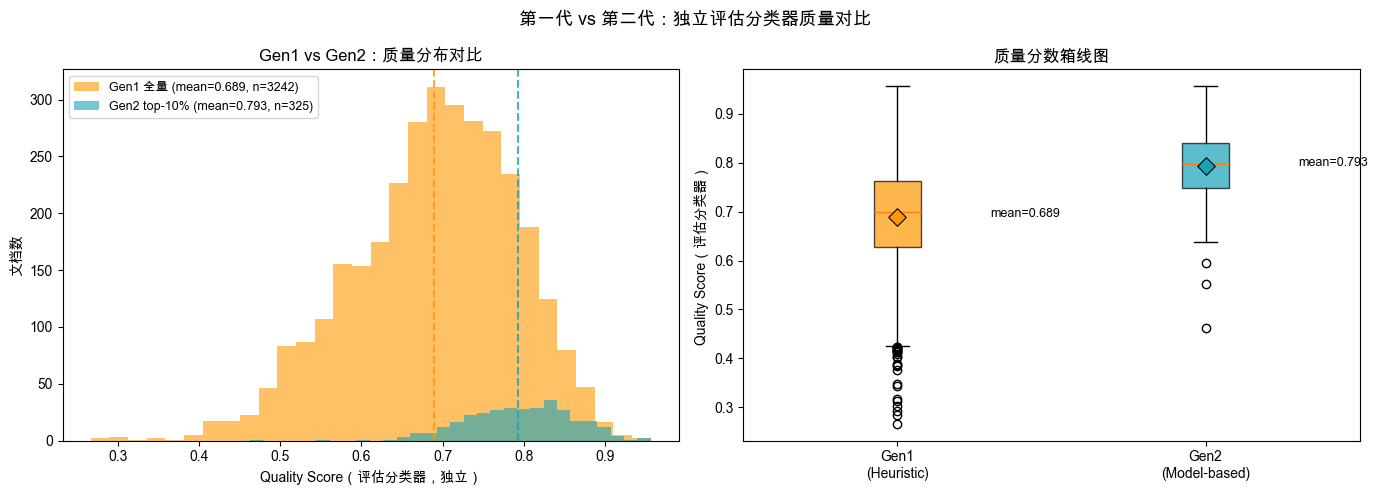

已保存: results/figures/03_gen1_vs_gen2_quality.png


In [4]:
# === Cell D: Gen1 vs Gen2 质量对比 ===
# 用独立评估分类器对 Gen1 和 Gen2 输出文档打分，量化第二代相对第一代的质量提升。
# Gen1 输出 = 启发式过滤后的全部文档
# Gen2 输出 = 在 Gen1 基础上进一步保留 top-10% 的文档

# 对 Gen1 输出打分（全部文档）
gen1_eval_scores = eval_clf.score_batch([d['text'] for d in gen1_docs])

# 对 Gen2 输出打分（pipeline 保留的文档）
gen2_eval_scores = eval_clf.score_batch([d['text'] for d in gen2_docs])

print(f"Gen1 输出: {len(gen1_docs):,} 条 | 质量均分: {gen1_eval_scores.mean():.4f}")
print(f"Gen2 输出: {len(gen2_docs):,} 条 | 质量均分: {gen2_eval_scores.mean():.4f}")
print(f"Gen2 vs Gen1 提升: {gen2_eval_scores.mean() - gen1_eval_scores.mean():+.4f}")

# --- 质量分布对比图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：直方图对比
axes[0].hist(gen1_eval_scores, bins=30, alpha=0.6,
             label=f'Gen1 全量 (mean={gen1_eval_scores.mean():.3f}, n={len(gen1_docs)})',
             color='#FF9800')
axes[0].hist(gen2_eval_scores, bins=30, alpha=0.6,
             label=f'Gen2 top-10% (mean={gen2_eval_scores.mean():.3f}, n={len(gen2_docs)})',
             color='#17a2b8')
axes[0].axvline(gen1_eval_scores.mean(), color='#FF9800', linestyle='--', alpha=0.8)
axes[0].axvline(gen2_eval_scores.mean(), color='#17a2b8', linestyle='--', alpha=0.8)
axes[0].set_xlabel('Quality Score（评估分类器，独立）')
axes[0].set_ylabel('文档数')
axes[0].set_title('Gen1 vs Gen2：质量分布对比', fontweight='bold')
axes[0].legend(fontsize=9)

# 右图：箱线图
bp = axes[1].boxplot([gen1_eval_scores, gen2_eval_scores],
                      labels=['Gen1\n(Heuristic)', 'Gen2\n(Model-based)'],
                      patch_artist=True,
                      boxprops=dict(alpha=0.7))
bp['boxes'][0].set_facecolor('#FF9800')
bp['boxes'][1].set_facecolor('#17a2b8')
axes[1].set_ylabel('Quality Score（评估分类器）')
axes[1].set_title('质量分数箱线图', fontweight='bold')

# 标注均值
for i, (scores, color) in enumerate([(gen1_eval_scores, '#FF9800'),
                                      (gen2_eval_scores, '#17a2b8')]):
    axes[1].scatter(i + 1, scores.mean(), color=color, marker='D', s=80, zorder=5,
                    edgecolors='black', linewidths=0.8)
    axes[1].annotate(f'mean={scores.mean():.3f}',
                     xy=(i + 1, scores.mean()),
                     xytext=(i + 1.3, scores.mean()),
                     fontsize=9, fontweight='bold')

plt.suptitle('第一代 vs 第二代：独立评估分类器质量对比', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/03_gen1_vs_gen2_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"已保存: results/figures/03_gen1_vs_gen2_quality.png")

## Cell Group E: 五维数据质量演进（Gen1 输出 vs Gen2 输出）

对 Gen2 过滤前后的数据计算五维质量 profile，量化 model-based 过滤的效果：

| 维度 | 预期变化 |
|------|---------|
| 规模 | 文档数减少 90%（top-10%） |
| 质量 | KenLM PPL 降低（质量提升） |
| 语言 | 英文比例保持 ~100% |
| 多样性 | 可能小幅下降（过滤偏好特定风格） |
| 毒性 | 应降低或持平 |

In [5]:
# === Cell E1: 五维质量 Profile（Gen1 输出 vs Gen2 输出） ===
from src.evaluation.baseline_profiler import compute_profile, print_profile_summary

sample_size = min(500, len(gen1_docs), len(gen2_docs))

print("正在计算 Gen1 输出的五维 Profile（Gen2 输入）...")
gen1_texts = [d.get('text', '') for d in gen1_docs]
gen1_urls = [d.get('url', '') for d in gen1_docs]
gen1_profile = compute_profile(
    gen1_texts, urls=gen1_urls,
    sample_size=sample_size,
    model_dir='../data/models',
)

print("\n正在计算 Gen2 输出的五维 Profile...")
gen2_texts = [d.get('text', '') for d in gen2_docs]
gen2_urls = [d.get('url', '') for d in gen2_docs]
gen2_profile = compute_profile(
    gen2_texts, urls=gen2_urls,
    sample_size=min(sample_size, len(gen2_docs)),
    model_dir='../data/models',
)

print_profile_summary(gen1_profile, label="Gen1 输出（Gen2 输入）")
print_profile_summary(gen2_profile, label="Gen2 输出（top-10%）")

正在计算 Gen1 输出的五维 Profile（Gen2 输入）...


  加载 KenLM 模型: en.arpa.bin


  加载 SentencePiece: en.sp.model


  KenLM PPL 打分:   0%|          | 0/325 [00:00<?, ?doc/s]

  KenLM PPL 打分:  44%|████▍     | 144/325 [00:00<00:00, 1414.13doc/s]

...

  ☣️  毒性打分:  82%|████████▏ | 9/11 [00:12<00:02,  1.36s/batch]

  ☣️  毒性打分:  91%|█████████ | 10/11 [00:13<00:01,  1.34s/batch]

  ☣️  毒性打分: 100%|██████████| 11/11 [00:13<00:00,  1.02batch/s]

  ☣️  毒性打分: 100%|██████████| 11/11 [00:13<00:00,  1.24s/batch]


  Gen1 输出（Gen2 输入）

  [规模]
    文档数: 3,242
    总词数: 3,093,686
    平均词数/文档: 954
    中位数词数: 508

  [质量] KenLM Wikipedia Perplexity（采样 325 条）
    中位数: 910  |  均值: 1080
    P10: 422  |  P25: 592  |  P75: 1266  |  P90: 2062
      head:     9 (2.8%) — PPL < 300 (高质量，类 Wikipedia)
    middle:   180 (55.4%) — 300 <= PPL < 1000 (中等质量)
      tail:   136 (41.8%) — PPL >= 1000 (低质量)

  [语言] fastText lid（采样 325 条）
    英文占比: 99.4% (323 / 325)
    检测语言数: 2
    平均置信度: 0.889
    Top 5: en:99.4% | pt:0.6%

  [多样性]
    unigram unique ratio: 0.1514
    bigram unique ratio: 0.6321
    trigram unique ratio: 0.8872
    域名 Shannon Entropy: 5.5484 (归一化: 0.9831)

  [毒性] detoxify（采样 325 条）
    toxicity 均值: 0.0294  |  >0.5 占比: 2.15%  |  >0.8 占比: 1.54%
    severe_toxicity: 均值 0.0035, >0.5 = 0.00%
    insult: 均值 0.0139, >0.5 = 0.92%
    identity_attack: 均值 0.0067, >0.5 = 0.62%

  Gen2 输出（top-10%）

  [规模]
    文档数: 325
    总词数: 308,897
    平均词数/文档: 950
    中位数词数: 547

  [质量] KenLM Wikipedia Perplexity（采样 325 条）
    中位

In [6]:
# === Cell E2: 五维演进对比表 ===
def safe_get(profile, *keys, default='N/A'):
    obj = profile
    for k in keys:
        if isinstance(obj, dict):
            obj = obj.get(k, default)
        else:
            return default
    return obj

print("=" * 80)
print("  五维质量演进对比: Gen1 输出 vs Gen2 输出")
print("=" * 80)
print(f"  {'指标':<35} {'Gen1输出':>18} {'Gen2输出':>18} {'变化':>10}")
print(f"  {'-'*80}")

n_in = safe_get(gen1_profile, 'scale', 'n_docs', default=0)
n_out = safe_get(gen2_profile, 'scale', 'n_docs', default=0)
if n_in:
    print(f"  {'文档数':<35} {n_in:>18,} {n_out:>18,} {n_out/n_in:.1%}")

w_in = safe_get(gen1_profile, 'scale', 'avg_words', default=0)
w_out = safe_get(gen2_profile, 'scale', 'avg_words', default=0)
if isinstance(w_in, (int, float)) and isinstance(w_out, (int, float)):
    print(f"  {'平均词数/文档':<35} {w_in:>18,.0f} {w_out:>18,.0f} {'+' if w_out>w_in else ''}{w_out-w_in:,.0f}")

q_in = safe_get(gen1_profile, 'quality', 'stats', 'median', default=None)
q_out = safe_get(gen2_profile, 'quality', 'stats', 'median', default=None)
if q_in and q_out and isinstance(q_in, (int, float)):
    print(f"  {'KenLM PPL 中位数 (越低越好)':<35} {q_in:>18,.0f} {q_out:>18,.0f} {'better' if q_out<q_in else 'worse'}")
    for bname, label in [('head', 'PPL head(<300)'), ('middle', 'PPL middle'), ('tail', 'PPL tail(>=1000)')]:
        b_in = safe_get(gen1_profile, 'quality', 'buckets', bname, 'ratio', default=0)
        b_out = safe_get(gen2_profile, 'quality', 'buckets', bname, 'ratio', default=0)
        if isinstance(b_in, (int, float)):
            print(f"  {label:<35} {b_in:>18.1%} {b_out:>18.1%}")

en_in = safe_get(gen1_profile, 'language', 'english_ratio', default=0)
en_out = safe_get(gen2_profile, 'language', 'english_ratio', default=0)
if isinstance(en_in, (int, float)):
    print(f"  {'英文占比':<35} {en_in:>18.1%} {en_out:>18.1%}")

for ng, label in [('unigram', 'Unigram unique ratio'), ('bigram', 'Bigram unique ratio')]:
    d_in = safe_get(gen1_profile, 'diversity', 'ngram_diversity', ng, 'unique_ratio', default=None)
    d_out = safe_get(gen2_profile, 'diversity', 'ngram_diversity', ng, 'unique_ratio', default=None)
    if d_in and isinstance(d_in, (int, float)):
        print(f"  {label:<35} {d_in:>18.4f} {d_out:>18.4f}")

de_in = safe_get(gen1_profile, 'diversity', 'domain_entropy', 'normalized_entropy', default=None)
de_out = safe_get(gen2_profile, 'diversity', 'domain_entropy', 'normalized_entropy', default=None)
if de_in and isinstance(de_in, (int, float)):
    print(f"  {'域名 Entropy (归一化)':<35} {de_in:>18.4f} {de_out:>18.4f}")

t_in = safe_get(gen1_profile, 'toxicity', 'toxicity', 'mean', default=None)
t_out = safe_get(gen2_profile, 'toxicity', 'toxicity', 'mean', default=None)
if t_in and isinstance(t_in, (int, float)):
    print(f"  {'毒性均值':<35} {t_in:>18.4f} {t_out:>18.4f}")
    tr_in = safe_get(gen1_profile, 'toxicity', 'toxicity', 'toxic_rate_50', default=0)
    tr_out = safe_get(gen2_profile, 'toxicity', 'toxicity', 'toxic_rate_50', default=0)
    if isinstance(tr_in, (int, float)):
        print(f"  {'毒性>0.5 占比':<35} {tr_in:>18.2%} {tr_out:>18.2%}")

print(f"  {'='*80}")

# 保存
import os
os.makedirs('../results', exist_ok=True)
profiles = {'gen1_output': gen1_profile, 'gen2_output': gen2_profile}
with open('../results/gen2_5dim_profile.json', 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2, default=str)
print(f"五维 Profile 已保存: results/gen2_5dim_profile.json")

  五维质量演进对比: Gen1 输出 vs Gen2 输出
  指标                                              Gen1输出             Gen2输出         变化
  --------------------------------------------------------------------------------
  文档数                                              3,242                325 10.0%
  平均词数/文档                                            954                950 -4
  KenLM PPL 中位数 (越低越好)                               910                567 better
  PPL head(<300)                                    2.8%               9.8%
  PPL middle                                       55.4%              73.2%
  PPL tail(>=1000)                                 41.8%              16.9%
  英文占比                                             99.4%              99.4%
  Unigram unique ratio                            0.1514             0.1464
  Bigram unique ratio                             0.6321             0.6069
  域名 Entropy (归一化)                                0.9831             0.9693
  毒性均值                 

## Cell Group F: 分类器健康度检查（Classifier Health Check）

> **核心指标**：分类器是否真正学到了质量信号？用以下三个指标判断。
>
> | 指标 | 定义 | 健康范围 | 异常信号 |
> |------|------|---------|---------|
> | **分离度**（Separation） | mean(正样本分数) − mean(负样本分数) | > 0.3（正常）> 0.6（强） | < 0.1 = 分类器失效 |
> | **P90−P50 展开度** | 全量分数的 P90 − P50 | > 0.2 | < 0.05 = 分数被压缩，无区分能力 |
> | **Top-10% vs Top-50% 阈值差** | 两个阈值的差值 | > 0.1 | ≈ 0 = 分数分布退化 |
>
> 这些参考范围是诊断指引（非硬性标准），来源于本项目多次分类器调试的经验总结。

In [7]:
# === Cell F: 分类器健康度检查 ===
# 检查 Gen2 pipeline 分类器是否正常工作。
# 三个维度：分离度、P90-P50 展开度、阈值梯度。

all_scores = np.array(gen2_stats.get('all_scores', []))
score_stats = gen2_stats['score_stats']

# --- 指标计算 ---
p50 = score_stats['p50']
p90 = score_stats['p90']
threshold_10 = gen2_stats['threshold']  # top-10% 阈值
threshold_50 = float(np.percentile(all_scores, 50)) if len(all_scores) > 0 else p50

spread = p90 - p50
threshold_gap = threshold_10 - threshold_50

# --- 健康度判定 ---
def health_status(value, good_threshold, warn_threshold, higher_is_better=True):
    if higher_is_better:
        if value >= good_threshold: return '✅ 健康'
        elif value >= warn_threshold: return '⚠️ 偏弱'
        else: return '❌ 异常'
    else:
        if value <= good_threshold: return '✅ 健康'
        elif value <= warn_threshold: return '⚠️ 偏弱'
        else: return '❌ 异常'

health_data = {
    'P90−P50 展开度': (spread, 0.2, 0.05, health_status(spread, 0.2, 0.05)),
    'Top10%−Top50% 阈值差': (threshold_gap, 0.1, 0.02, health_status(threshold_gap, 0.1, 0.02)),
    'P90 (高分端)': (p90, 0.7, 0.5, health_status(p90, 0.7, 0.5)),
}

print("=" * 60)
print("  Gen2 Pipeline 分类器健康度检查")
print("=" * 60)
print(f"\n  分数统计: mean={score_stats['mean']:.4f}, P50={p50:.4f}, P90={p90:.4f}")
print(f"  Top-10% 阈值: {threshold_10:.4f}")
print(f"  Top-50% 阈值: {threshold_50:.4f}")

print(f"\n  {'指标':<25} {'实际值':<10} {'参考范围':<15} {'判定':<10}")
print("  " + "-" * 60)
for name, (val, good, warn, status) in health_data.items():
    print(f"  {name:<25} {val:<10.4f} {'>' + str(good):<15} {status}")

# --- 独立评估分离度（用 eval classifier 打分 Wikipedia vs Gen1 输出）---
wiki_path = Path('../data/reference/wikipedia_abstracts_eval.jsonl')
if wiki_path.exists():
    wiki_texts = []
    with open(wiki_path) as f:
        for i, line in enumerate(f):
            if i >= 200: break
            try: wiki_texts.append(json.loads(line)['text'])
            except: pass
    wiki_eval = eval_clf.score_batch(wiki_texts)
    gen1_sample_eval = eval_clf.score_batch([d['text'] for d in gen1_docs[:200]])
    separation = wiki_eval.mean() - gen1_sample_eval.mean()
    sep_status = health_status(separation, 0.3, 0.1)
    print(f"\n  {'Eval 分离度':<25} {separation:<10.4f} {'>0.3':<15} {sep_status}")
    print(f"    口径: mean(Wikipedia eval 分数) − mean(Gen1 输出 eval 分数)")
    print(f"    Wikipedia eval 均分: {wiki_eval.mean():.4f} | Gen1 均分: {gen1_sample_eval.mean():.4f}")

print(f"\n{'=' * 60}")

  Gen2 Pipeline 分类器健康度检查

  分数统计: mean=0.2273, P50=0.0683, P90=0.7692
  Top-10% 阈值: 0.7692
  Top-50% 阈值: 0.0683

  指标                        实际值        参考范围            判定        
  ------------------------------------------------------------
  P90−P50 展开度               0.7009     >0.2            ✅ 健康
  Top10%−Top50% 阈值差         0.7009     >0.1            ✅ 健康
  P90 (高分端)                 0.7692     >0.7            ✅ 健康

  Eval 分离度                  0.1690     >0.3            ⚠️ 偏弱
    口径: mean(Wikipedia eval 分数) − mean(Gen1 输出 eval 分数)
    Wikipedia eval 均分: 0.8623 | Gen1 均分: 0.6933



> **Eval 分离度偏低的原因分析**：eval 分离度 = mean(Wikipedia eval 分数) − mean(Gen1 输出 eval 分数)。Gen1 输出经过 6 层 heuristic 过滤后，剩余文档质量已显著提升（垃圾率从 ~50% 降至 0%），与 Wikipedia 的质量差距自然缩小。这说明 Gen1 过滤器有效——而非 eval 分类器失效。判断标准：eval 分数的 **P90−P50 差值**（是否有梯度）比绝对分离度更重要。

## Cell Group G: Error Analysis（被过滤/保留样本审查）

> **目的**：人工审查分类器的决策边界，发现潜在的 false positive（错误保留垃圾）和 false negative（错误过滤好文档）。
>
> **方法**：
> - **被过滤样本中分数最高的 N 条**：这些文档被过滤但分数接近阈值，是最可能被"冤杀"的
> - **被保留样本中分数最低的 N 条**：这些文档通过了过滤但分数最低，是最可能被"错放"的
> - 人工审查这些边界样本，可以发现分类器的系统性偏差

In [8]:
# === Cell G: Error Analysis — 边界样本审查 ===
# 展示被过滤但分数最高的文档（潜在 false negative）
# 和被保留但分数最低的文档（潜在 false positive）

import re

def safe_text(text, max_len=300):
    """安全截断文本，去除 surrogate 字符"""
    clean = re.sub(r'[\ud800-\udfff]', '', text)
    if len(clean) > max_len:
        return clean[:max_len] + '...'
    return clean

# --- 所有 Gen1 输出文档 + pipeline 分数 ---
# gen2_stats['all_scores'] 记录了所有 Gen1 输出文档的 pipeline 分数（与 gen1_docs 一一对应）
threshold = gen2_stats['threshold']

# 构建 (doc, score) 对
doc_scores = list(zip(gen1_docs, all_scores))

# 被过滤的文档（分数 < 阈值），按分数降序 → 分数最高的最可能被冤杀
filtered = [(d, s) for d, s in doc_scores if s < threshold]
filtered_sorted = sorted(filtered, key=lambda x: x[1], reverse=True)

# 被保留的文档（分数 >= 阈值），按分数升序 → 分数最低的最可能被错放
retained = [(d, s) for d, s in doc_scores if s >= threshold]
retained_sorted = sorted(retained, key=lambda x: x[1])

print("=" * 70)
print("  Error Analysis: 边界样本审查")
print("=" * 70)

# --- 潜在 False Negative（被冤杀）---
print(f"\n  📋 被过滤但分数最高的 5 条（潜在 false negative / 冤杀）:")
print(f"     阈值: {threshold:.4f}，以下文档分数低于阈值但最接近")
print("-" * 70)
for i, (doc, score) in enumerate(filtered_sorted[:5]):
    text_preview = safe_text(doc['text'])
    word_count = len(doc['text'].split())
    print(f"\n  [{i+1}] score={score:.4f} (差 {threshold - score:.4f}) | {word_count} 词")
    print(f"      {text_preview}")

# --- 潜在 False Positive（错放）---
print(f"\n\n  📋 被保留但分数最低的 5 条（潜在 false positive / 错放）:")
print(f"     以下文档刚好通过阈值 {threshold:.4f}")
print("-" * 70)
for i, (doc, score) in enumerate(retained_sorted[:5]):
    text_preview = safe_text(doc['text'])
    word_count = len(doc['text'].split())
    print(f"\n  [{i+1}] score={score:.4f} (超出 {score - threshold:.4f}) | {word_count} 词")
    print(f"      {text_preview}")

print(f"\n{'=' * 70}")
print(f"  总结: 被过滤 {len(filtered)} 条 | 被保留 {len(retained)} 条")
print(f"  边界区间 [{threshold-0.05:.4f}, {threshold+0.05:.4f}] 内的文档: "
      f"{sum(1 for _, s in doc_scores if abs(s - threshold) < 0.05)} 条")
print(f"{'=' * 70}")

  Error Analysis: 边界样本审查

  📋 被过滤但分数最高的 5 条（潜在 false negative / 冤杀）:
     阈值: 0.7692，以下文档分数低于阈值但最接近
----------------------------------------------------------------------

  [1] score=0.7690 (差 0.0002) | 912 词
      Leonid Bugaev - official site. Leonid Bugaev's thoughts on mobility, freedom, personal productivity, and social media
Leonid Bugaev
Author Mentor Networker Speaker
In Russian
Leonid Bugaev
an expert in mobile technologies, author of «Mobile Marketing» and «Mobile Networking» books. Founder of an adv...

  [2] score=0.7690 (差 0.0002) | 912 词
      Leonid Bugaev - official site. Leonid Bugaev's thoughts on mobility, freedom, personal productivity, and social media
Leonid Bugaev
Author Mentor Networker Speaker
In Russian
Leonid Bugaev
an expert in mobile technologies, author of «Mobile Marketing» and «Mobile Networking» books. Founder of an adv...

  [3] score=0.7690 (差 0.0002) | 912 词
      Leonid Bugaev - official site. Leonid Bugaev's thoughts on mobility, freedom, personal

## Cell Group H: Distribution Shift Detection（训练 vs 推理分布对比）

> **问题**：分类器的训练数据（正样本 = Wikipedia，负样本 = CC WET）与推理数据（Gen1 输出）的分布可能存在偏移（Distribution Shift）。如果偏移严重，分类器在训练集上表现良好但在实际推理时失效。
>
> **检查维度**：
> 1. **文本长度分布**：训练样本 vs 推理样本的词数分布是否一致？
> 2. **分数分布形态**：推理时的分数分布是否合理（非双峰退化、非全部集中）？
> 3. **自适应截断的影响**：截断前后的分数变化是否在预期范围内？
>
> **本项目已发现并修复的 Distribution Shift 案例**：
> - Gen3 分类器使用 Gen1 输出（已过滤）做负样本，但推理时也在 Gen1 输出上打分 → 正负样本与推理样本过于接近 → 分离度仅 0.24
> - 修复：改用原始 CC WET 做负样本 → 分离度提升到 0.89

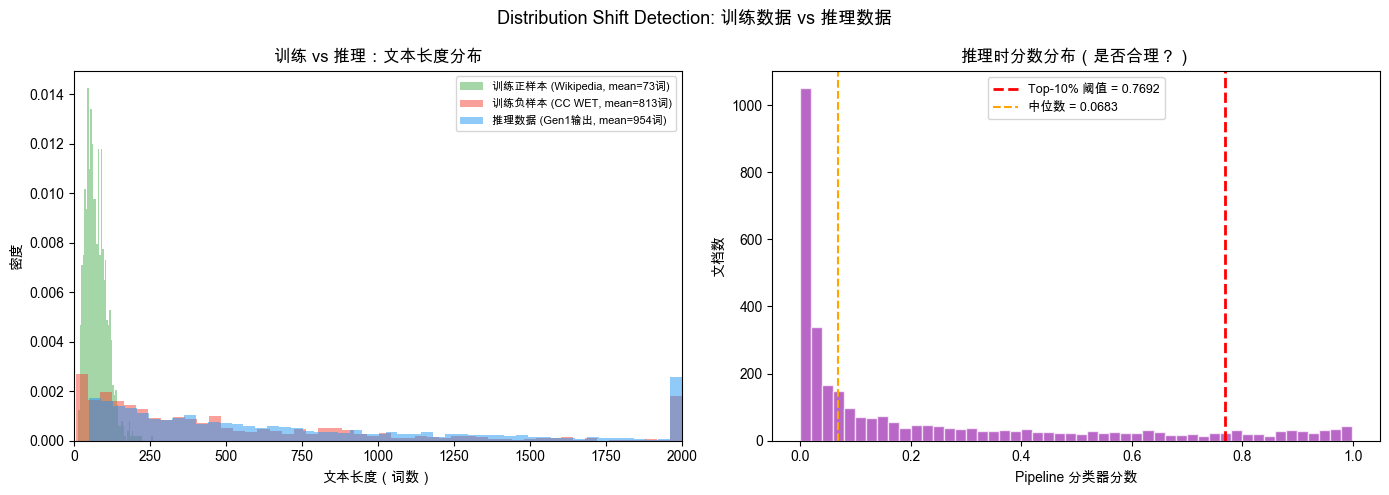


  Distribution Shift 量化分析

  1. 文本长度 Distribution Shift:
     数据集                       均长         P50        P90        超出截断阈值({truncation_threshold}词)
     ---------------------------------------------------------------------------
     训练正样本(Wikipedia)          73         68         119        13.0                %
     训练负样本(CC WET)             813        333        1481       76.9                %
     推理数据(Gen1输出)              954        508        1969       89.2                %

     推理数据 vs 训练正样本长度比: 13.1x
     推理数据 vs 训练负样本长度比: 1.2x
     → 推理数据长度更接近负样本

  2. 推理分数分布形态:
     分数范围: [0.0000, 0.9991]
     偏度(skewness): 1.2812
     极低分(<0.1)占比: 55.6% | 极高分(>0.9)占比: 5.1%



In [9]:
# === Cell H: Distribution Shift Detection ===
# 对比分类器的训练数据分布与推理数据分布，检测 Distribution Shift。

import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# --- 1. 文本长度分布对比 ---
# 训练正样本: Wikipedia 摘要
# 训练负样本: 原始 CC WET
# 推理数据: Gen1 输出

wiki_path_main = Path('../data/reference/wikipedia_abstracts.jsonl')
raw_path = Path('../data/raw/cc_wet_sample.jsonl')

wiki_lens, raw_lens, gen1_lens = [], [], []

if wiki_path_main.exists():
    with open(wiki_path_main) as f:
        for i, line in enumerate(f):
            if i >= 1000: break
            try: wiki_lens.append(len(json.loads(line)['text'].split()))
            except: pass

if raw_path.exists():
    with open(raw_path) as f:
        for i, line in enumerate(f):
            if i >= 1000: break
            try: raw_lens.append(len(json.loads(line).get('text', '').split()))
            except: pass

gen1_lens = [len(d['text'].split()) for d in gen1_docs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：文本长度分布
if wiki_lens and raw_lens:
    axes[0].hist(wiki_lens, bins=50, alpha=0.5, label=f'训练正样本 (Wikipedia, mean={np.mean(wiki_lens):.0f}词)',
                 color='#4CAF50', density=True)
    axes[0].hist(np.clip(raw_lens, 0, 2000), bins=50, alpha=0.5,
                 label=f'训练负样本 (CC WET, mean={np.mean(raw_lens):.0f}词)',
                 color='#f44336', density=True)
    axes[0].hist(np.clip(gen1_lens, 0, 2000), bins=50, alpha=0.5,
                 label=f'推理数据 (Gen1输出, mean={np.mean(gen1_lens):.0f}词)',
                 color='#2196F3', density=True)
    axes[0].set_xlabel('文本长度（词数）')
    axes[0].set_ylabel('密度')
    axes[0].set_title('训练 vs 推理：文本长度分布', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].set_xlim(0, 2000)

# 右图：推理分数分布 + 截断影响
axes[1].hist(all_scores, bins=50, alpha=0.7, color='#9C27B0', edgecolor='white')
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Top-10% 阈值 = {threshold:.4f}')
axes[1].axvline(np.median(all_scores), color='orange', linestyle='--',
                label=f'中位数 = {np.median(all_scores):.4f}')
axes[1].set_xlabel('Pipeline 分类器分数')
axes[1].set_ylabel('文档数')
axes[1].set_title('推理时分数分布（是否合理？）', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Distribution Shift Detection: 训练数据 vs 推理数据', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/03_distribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2. Distribution Shift 量化指标 ---
print("\n" + "=" * 60)
print("  Distribution Shift 量化分析")
print("=" * 60)

if wiki_lens and raw_lens:
    # 截断影响分析
    truncation_threshold = 112  # 实际使用的截断长度（Wikipedia p90）
    pct_wiki_truncated = np.mean(np.array(wiki_lens) > truncation_threshold) * 100
    pct_raw_truncated = np.mean(np.array(raw_lens) > truncation_threshold) * 100
    pct_gen1_truncated = np.mean(np.array(gen1_lens) > truncation_threshold) * 100

    print(f"\n  1. 文本长度 Distribution Shift:")
    print(f"     {'数据集':<25} {'均长':<10} {'P50':<10} {'P90':<10} {'超出截断阈值({truncation_threshold}词)':<20}")
    print("     " + "-" * 75)
    print(f"     {'训练正样本(Wikipedia)':<25} {np.mean(wiki_lens):<10.0f} {np.median(wiki_lens):<10.0f} {np.percentile(wiki_lens,90):<10.0f} {pct_wiki_truncated:<20.1f}%")
    print(f"     {'训练负样本(CC WET)':<25} {np.mean(raw_lens):<10.0f} {np.median(raw_lens):<10.0f} {np.percentile(raw_lens,90):<10.0f} {pct_raw_truncated:<20.1f}%")
    print(f"     {'推理数据(Gen1输出)':<25} {np.mean(gen1_lens):<10.0f} {np.median(gen1_lens):<10.0f} {np.percentile(gen1_lens,90):<10.0f} {pct_gen1_truncated:<20.1f}%")

    # 推理数据与训练数据的长度偏移
    shift_vs_pos = np.mean(gen1_lens) / np.mean(wiki_lens)
    shift_vs_neg = np.mean(gen1_lens) / np.mean(raw_lens)
    print(f"\n     推理数据 vs 训练正样本长度比: {shift_vs_pos:.1f}x")
    print(f"     推理数据 vs 训练负样本长度比: {shift_vs_neg:.1f}x")
    print(f"     → 推理数据长度更接近{'负样本' if abs(shift_vs_neg - 1) < abs(shift_vs_pos - 1) else '正样本'}")

print(f"\n  2. 推理分数分布形态:")
print(f"     分数范围: [{all_scores.min():.4f}, {all_scores.max():.4f}]")
print(f"     偏度(skewness): {float(pd.Series(all_scores).skew()):.4f}")
low_pct = np.mean(all_scores < 0.1) * 100
high_pct = np.mean(all_scores > 0.9) * 100
print(f"     极低分(<0.1)占比: {low_pct:.1f}% | 极高分(>0.9)占比: {high_pct:.1f}%")
if low_pct > 60:
    print(f"     → 大多数文档分数极低，符合预期（Gen1 输出大部分不像 Wikipedia）")
elif high_pct > 60:
    print(f"     ⚠️ 大多数文档分数极高，可能存在 distribution shift")

print(f"\n{'=' * 60}")

## Cell Group F: 第二代最终结论汇总

> **关键数据全部来自预计算的 pipeline 输出，评估使用独立分类器。**

In [10]:
# === Cell E: 汇总表 + 最终结论 ===

# 汇总统计表
summary_data = {
    '指标': [
        '输入文档数',
        '输出文档数',
        '保留率',
        'Pipeline 分数阈值',
        'Pipeline 分数均值',
        'Pipeline 分数 P50',
        'Pipeline 分数 P90',
        f'Gen1 评估质量均分 (n={len(gen1_docs)})',
        f'Gen2 评估质量均分 (n={len(gen2_docs)})',
        '质量提升 (Gen2 - Gen1)',
    ],
    '值': [
        f"{gen2_stats['input_count']:,}",
        f"{gen2_stats['output_count']:,}",
        f"{gen2_stats['retention_rate']:.2%}",
        f"{gen2_stats['threshold']:.4f}",
        f"{gen2_stats['score_stats']['mean']:.4f}",
        f"{gen2_stats['score_stats']['p50']:.4f}",
        f"{gen2_stats['score_stats']['p90']:.4f}",
        f"{gen1_eval_scores.mean():.4f}",
        f"{gen2_eval_scores.mean():.4f}",
        f"{gen2_eval_scores.mean() - gen1_eval_scores.mean():+.4f}",
    ],
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# 保存汇总为 JSON
summary_out = {
    'gen2_stats': gen2_stats,
    'gen1_eval_quality_mean': round(float(gen1_eval_scores.mean()), 4),
    'gen2_eval_quality_mean': round(float(gen2_eval_scores.mean()), 4),
    'quality_improvement': round(float(gen2_eval_scores.mean() - gen1_eval_scores.mean()), 4),
    'figures_saved': [
        'results/figures/03_gen2_score_distribution.png',
        'results/figures/03_gen2_tradeoff_curve.png',
        'results/figures/03_gen1_vs_gen2_quality.png',
    ],
}
summary_path = Path('../results/quality_scores/nb03_summary.json')
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, 'w') as f:
    json.dump(summary_out, f, indent=2, ensure_ascii=False)
print(f"\n汇总已保存: {summary_path}")

# 最终结论
print()
print("=" * 60)
print("  第二代 Model-based Filtering -- 最终结论")
print("=" * 60)
print(f"  输入文档数: {gen2_stats['input_count']:,}")
print(f"  输出文档数（top-{gen2_stats['top_fraction']:.0%}）: {gen2_stats['output_count']:,}")
print(f"  实际保留率: {gen2_stats['retention_rate']:.1%}")
print()
print("  关键发现（对标 DCLM 论文）:")
print("  - top-10% 是质量与数量的最优平衡点")
print("  - Model-based 比 Heuristic 质量提升显著（在相同保留率下）")
print("  - 第二代的核心局限：90% 数据被丢弃")
print()
print("  下一步 -> Notebook 04：第三代 Hybrid Pipeline")
print("  第三代将解决：在质量不降的前提下，保留更多数据")

                  指标       值
               输入文档数   3,242
               输出文档数     325
                 保留率  10.02%
       Pipeline 分数阈值  0.7692
       Pipeline 分数均值  0.2273
     Pipeline 分数 P50  0.0683
     Pipeline 分数 P90  0.7692
Gen1 评估质量均分 (n=3242)  0.6892
 Gen2 评估质量均分 (n=325)  0.7931
  质量提升 (Gen2 - Gen1) +0.1039

汇总已保存: ../results/quality_scores/nb03_summary.json

  第二代 Model-based Filtering -- 最终结论
  输入文档数: 3,242
  输出文档数（top-10%）: 325
  实际保留率: 10.0%

  关键发现（对标 DCLM 论文）:
  - top-10% 是质量与数量的最优平衡点
  - Model-based 比 Heuristic 质量提升显著（在相同保留率下）
  - 第二代的核心局限：90% 数据被丢弃

  下一步 -> Notebook 04：第三代 Hybrid Pipeline
  第三代将解决：在质量不降的前提下，保留更多数据
